In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
df = pd.read_csv("smartcart_customers.csv")

In [136]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [137]:
df.shape

(2240, 22)

In [138]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [139]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [140]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [141]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature engineering

In [142]:
## age
# clustering algorithms are not that good for date type of features so we have to extract some meaningfull features from date values such as age, customer tenure

# we have year birth -> extract age because age would be a very good feature to have
# Age
df["Age"] = 2026-df["Year_Birth"]

In [143]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [144]:
## customer joining date
# we have given joining date of customer from we can extract a meaningfull feature that is customer tenure means how much days have been passed since customer joined
# ab ham actually ab tak kitne din hue wo nhi nikalenge ham ek refference date lenge jo ki recent date hogi jab kisi customer ne join kiya and uska tenure will be 0 and uske refference se baki ka jaise kisis customer in isse 5 days pahle join kiya tha to uska tenure 5 hoga and if any customer have joined 2 days before this most recent then his tenure will be 2
# we could have use todays date as by datetime.now to calculate exact tenure but we have not done this because if we will do this everytime we run the code after some days value will got change so data will be not fixed so thats why we have not done this here
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True) # we have to convert it to datetime befor so we can perform calculation according to datetime , and dayfirst is true because we have date given as day/month/year bu pandas aspect as month/day/year so it is not according to aspectation so we have to mention dayfirst is true

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date-df["Dt_Customer"]).dt.days

In [145]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [146]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [147]:
# spending - now we have spending of customers in each such as wines , fruits, meat etc we will add all and find out total spending of customer and that will be our new feature
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]
+df["MntMeatProducts"]+df["MntFishProducts"]
+df["MntSweetProducts"]+df["MntGoldProds"]

0       176
1         7
2        63
3         8
4        42
       ... 
2235    365
2236      8
2237     36
2238     91
2239     22
Length: 2240, dtype: int64

In [148]:
# total children -> now we have kids and teenagers of customers at their home we will make a new column of total children where we will have add kids + teenage
df["Total_Childrens"]= df["Kidhome"]+df["Teenhome"]

In [149]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,723,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,12,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,475,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,15,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,216,1


In [150]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,723,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,12,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,475,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,15,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,216,1


In [151]:
# Education
df["Education"].value_counts()

''' 
currently we have data in 
categories = [graduation,phdmmaster,2n cycle, basic]
we will convert that data into only three categories 
that will be 
1) Undergraduate -> Basic+2n Cycle
2) Graduate -> Graduation
3) Postgraduate -> Master + PhD
'''

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
})

In [152]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [153]:
# Marital Status
df["Marital_Status"].value_counts()

'''
we will create a new feature that will be living with 
if marital status is married together then it will be 
living with partner  else alone
'''

df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone",
    "YOLO":"Alone"
})

In [154]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [155]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,723,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,12,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,475,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,15,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,216,1,Partner


In [156]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [157]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,723,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,12,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,475,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,15,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,216,1,Partner


In [158]:
df_cleaned.shape

(2240, 15)

# Outliers

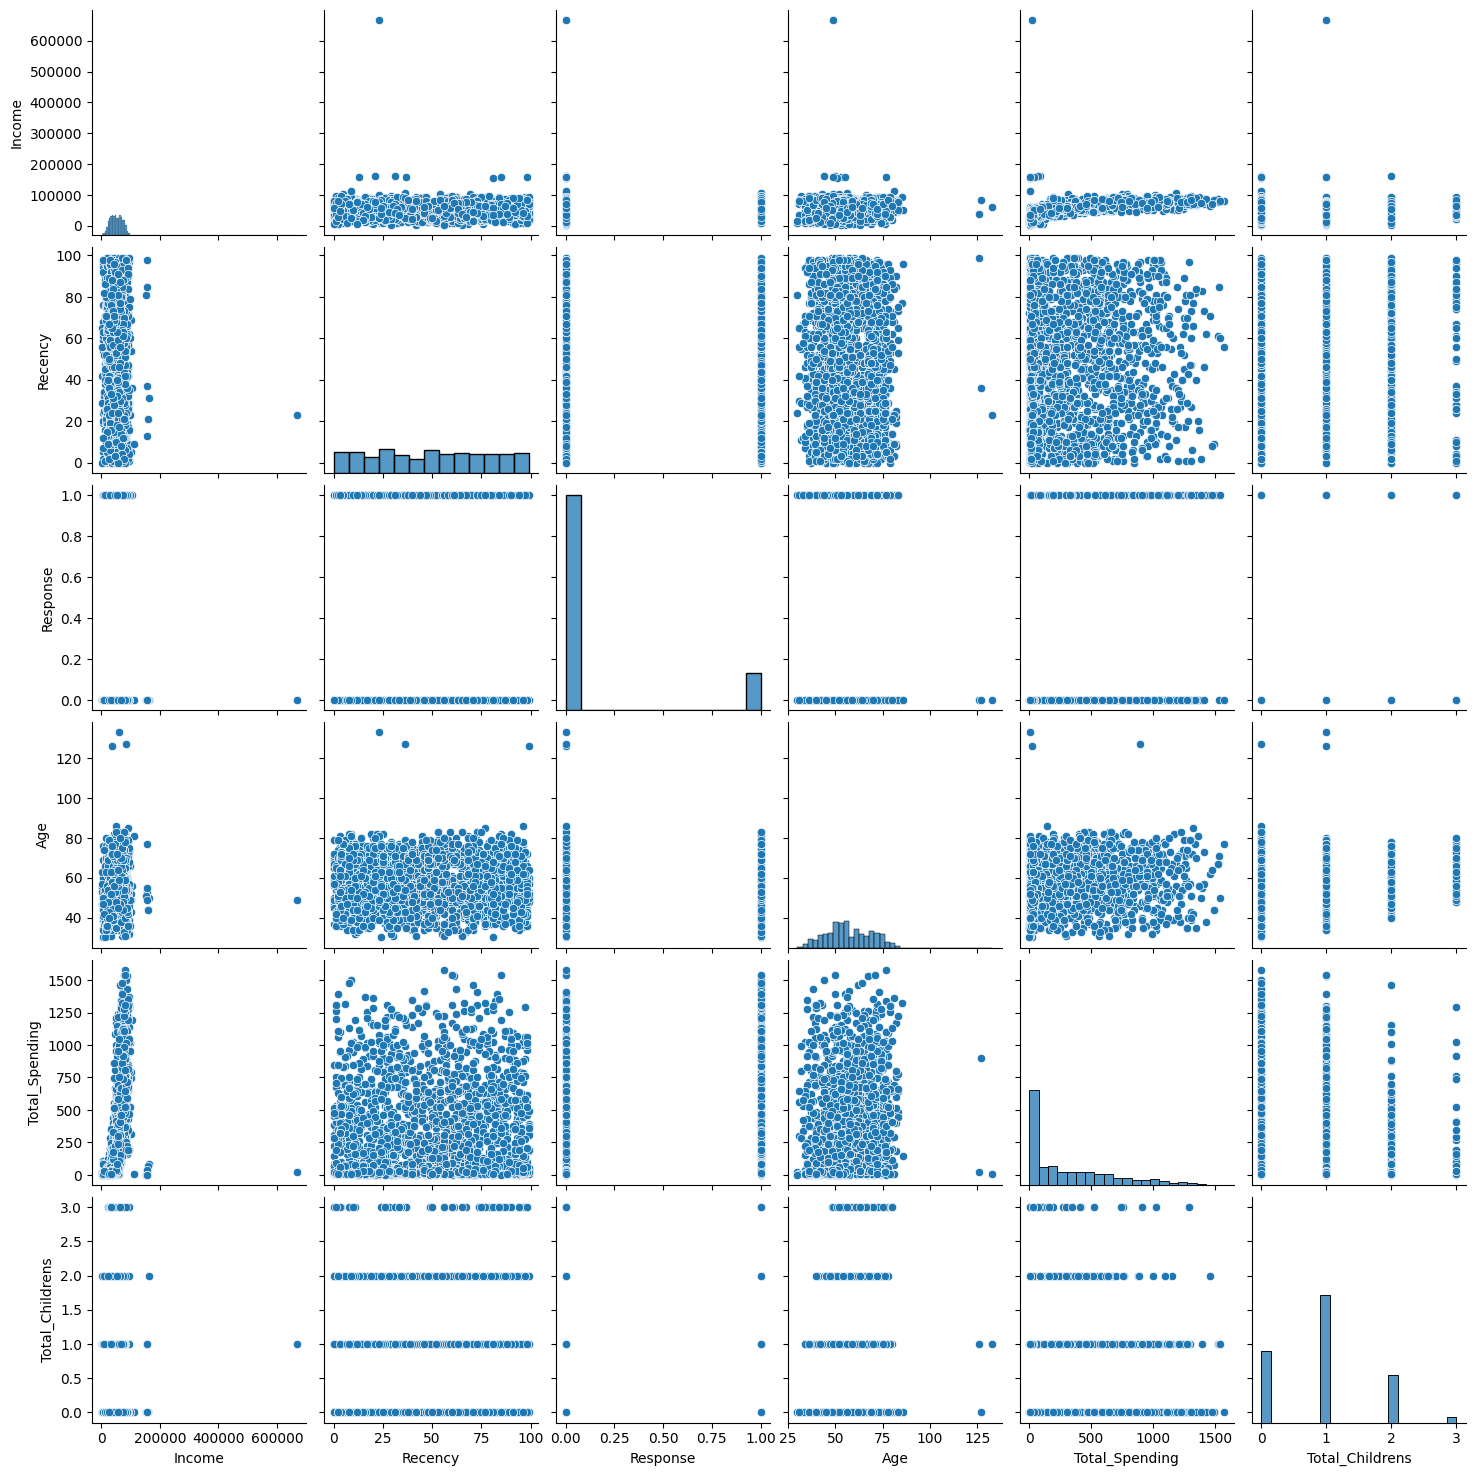

In [159]:
# select numerical columns
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Childrens"]

# relative plots of some features - pairplots
sns.pairplot(df_cleaned[cols])  # isse cols ke andar har feature ka her doosre feature including itself ke sath plot create ho jayega

In [160]:
# by looking at above graph we can see at outliers which we have to remove
''' 
in income columns their is a customer whose age is 
greater then 600k so we have to remove that

in age columns their are some customer whose age is greater
then 120 which is practically not possible so we will remove 
that 

'''

' \nin income columns their is a customer whose age is \ngreater then 600k so we have to remove that\n\nin age columns their are some customer whose age is greater\nthen 120 which is practically not possible so we will remove \nthat \n\n'

In [161]:
# Remove the outliers 
print("data size with outliers:",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600000)]

print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [162]:
corr = df_cleaned.corr(numeric_only=True)

In [163]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.709158,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.015104,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.004167,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.548924,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.658328,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.662844,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.351454,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.034528,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.249298,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.156370,0.095512


' \nfrom heatmap wo features ke pairs nikalo jinka strong\npositive correlation hai and strong negative correlation hai\n'

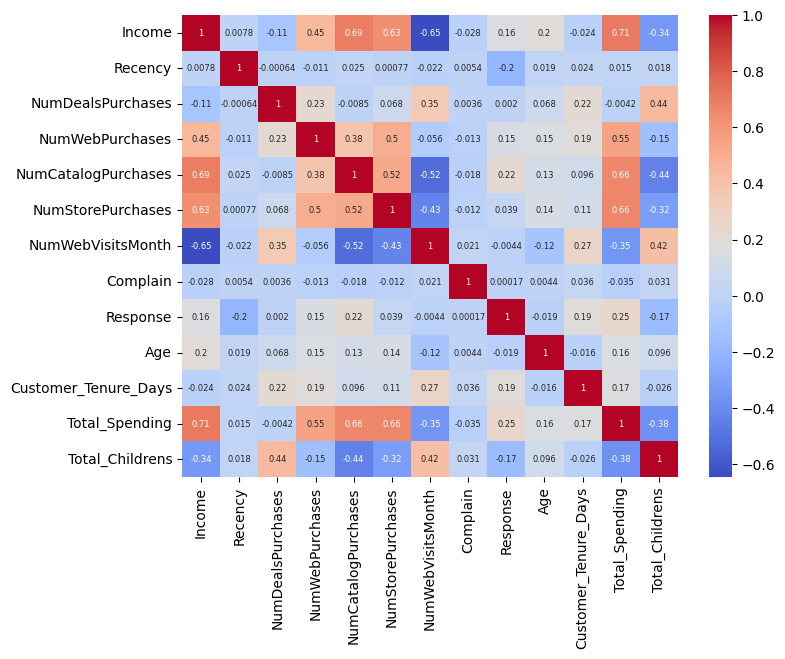

In [164]:
plt.figure(figsize=(8,6) )
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

''' 
from heatmap wo features ke pairs nikalo jinka strong
positive correlation hai and strong negative correlation hai
'''

# Encoding

In [165]:
from sklearn.preprocessing import OneHotEncoder

In [166]:
# by encoding we convert categorical columns to numeric
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])  # we get encoded columns and we have to transform that columns to dataframe and then add to our df

# we dont have to do drop first = true for clustering problem we do drop first = true to avoid problem of multicollinearity and that problem is seen in linear models not clustering infact by doing dropfirst true we can do like drop important meaningfull data that can be meaningfull for clusters and we are dropping so we dot do dropfirst for clustering

In [167]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [168]:
# lets concatenate enc df with original dataset

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [169]:
df_encoded.shape

(2236, 18)

In [170]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,723,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,12,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,475,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,15,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,216,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [171]:
# in scaling we standardize our data in same scale so machine cant be biased on the basis of large values or low values 
from sklearn.preprocessing import StandardScaler

In [172]:
X = df_encoded

In [173]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [174]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualize

In [175]:
X_scaled.shape

(2236, 18)

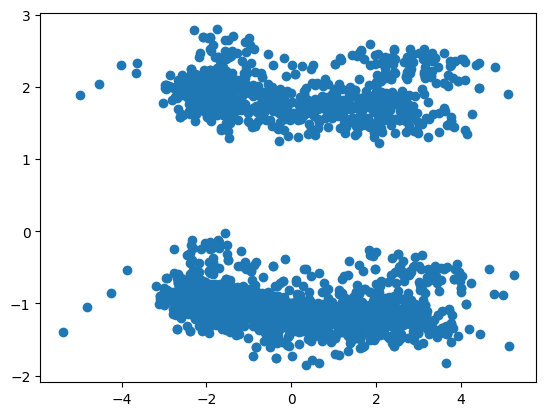

In [176]:
# currently we have 18 features so we cant visualize in 18 dimension so we will have to do pca for visualizating and convert it to 2d or 3d

# 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# plot
plt.scatter(X_pca[:,0],X_pca[:,1])

In [177]:
pca.explained_variance_ratio_  # here very less variance is captured so we can increase dimension from 2 to 3 so we can capture more variance 
# 33 percent info is captured 

array([0.22405146, 0.11389802])

Text(0.5, 0.92, '3d projecetion')

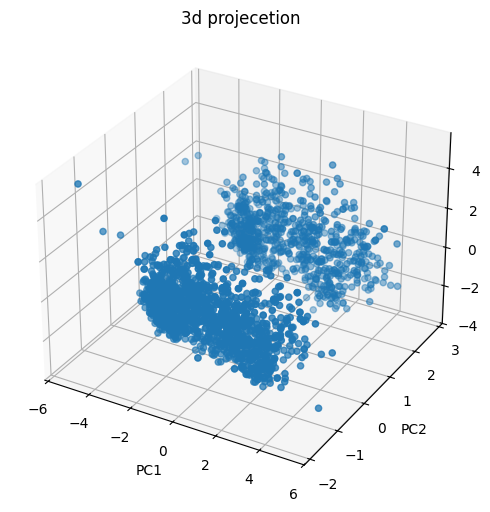

In [178]:
# 3D

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3d projecetion")

In [179]:
pca.explained_variance_ratio_
# here 44 % info is captured

array([0.22405146, 0.11389802, 0.10539994])

## Analyze K value
### 1.Elbow Method

In [180]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [181]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [182]:
print("best k = ",optimal_k)

best k =  4


Text(0, 0.5, 'WCSS')

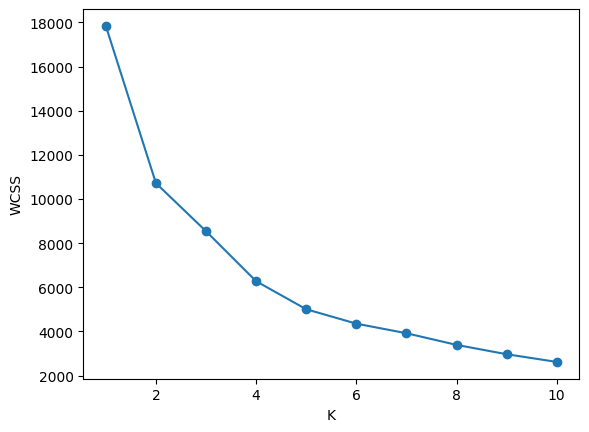

In [183]:
# we can also draw plot to visualy visualize where is elbow point 
plt.plot(range(1,11),wcss,marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

### 2.Silhoute Score

Text(0, 0.5, 'silhoute score')

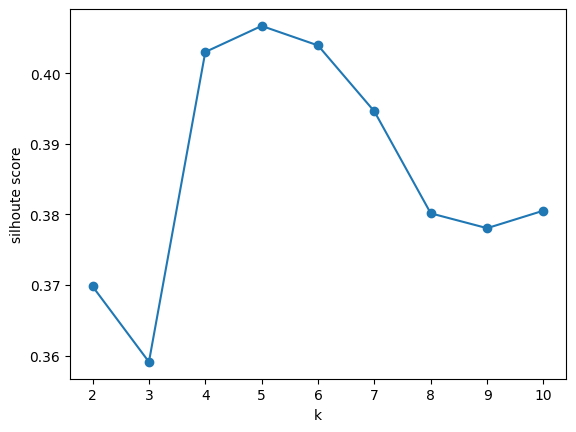

In [184]:
from sklearn.metrics import silhouette_score

scores = []

for k in range (2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

# plot 
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")
plt.ylabel("silhoute score")

Text(0, 0.5, 'SS')

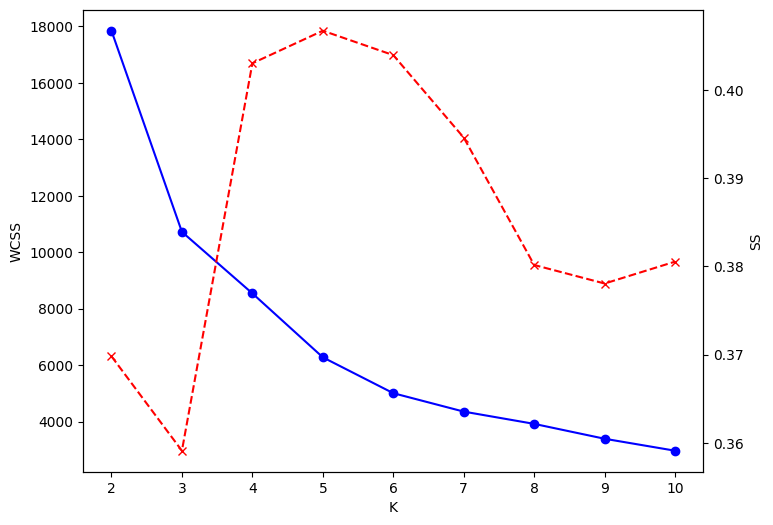

In [185]:
# how to select k value
''' 
kmeans++ -> in this we select knee value of wcss vs k plot

silhoute score -> in this we slect k value for which silhoute
                   score is maximum

  ## if we are looking at both ##
plot k vs wcss and k vs silhoute score in same plot
now pick the nearest k value point where both are intersecting
because we want a balance of both

'''
# combined plot

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color='red',linestyle="--")
ax2.set_ylabel("SS")

# this is how we plot two plots having not same range  in y in single graph

# optimal k = 4 -> both are intersecting around 4


# Clustering

In [186]:
# K_means

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

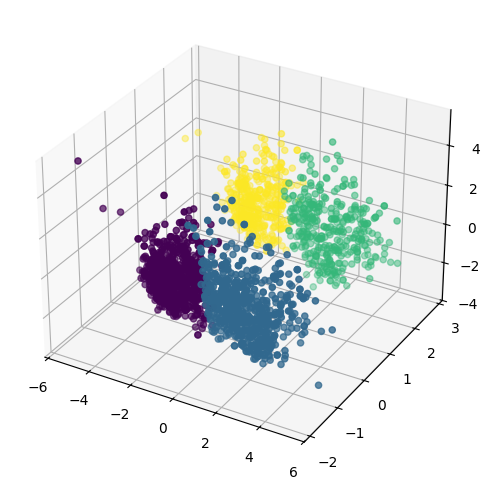

In [187]:
# visualize -> 3d plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)


In [188]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [189]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

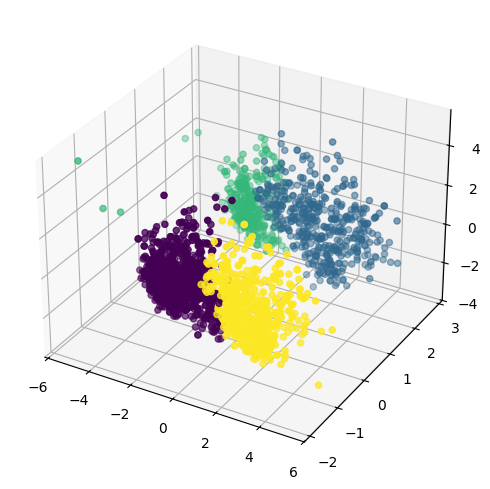

In [190]:
# visualize -> 3d plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [191]:
# we will pick that jisne better clustering ki hai here both have done perfect clustering and will do characterization on clusters we are not applying dbscan beacuse it will genrate 30+ clusters which we dont want to have too many clusters here
# we will choose kmeans wala cluster

# Characterization of Clusters

In [192]:
# add labels with original data -> X => because it is encoded so all are numeric we will not have any problem while calculating mean in summaray outliers are already removed here and it is cleaned already we are not using x_pca beacuse we want all features and not using x_scaled becasue we want data in original scale
X["Clusters"] = labels_kmeans

In [193]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,723,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,113,12,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,475,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,15,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,216,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

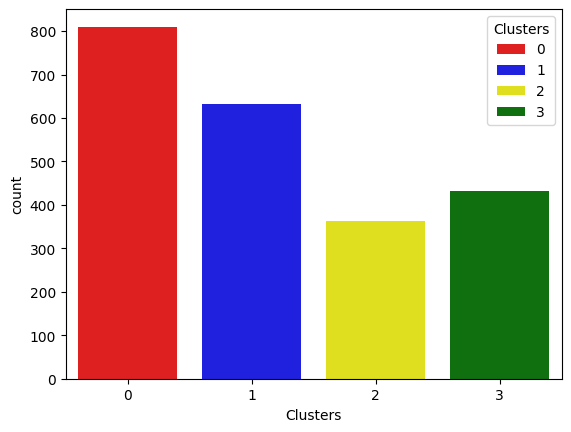

In [194]:
# create a color palate for 4 different types of customers(4 labels)
pal = ["red","blue","yellow","green"]

# lets count how many customers are in clusters 
sns.countplot(x=X["Clusters"],palette=pal,hue=X["Clusters"])

In [195]:
''' 
we have selected pair of features which are most interrelated
by plotting heatmap earlier lets see our clusters on that paired
features
'''


' \nwe have selected pair of features which are most interrelated\nby plotting heatmap earlier lets see our clusters on that paired\nfeatures\n'

<Axes: xlabel='Total_Spending', ylabel='Income'>

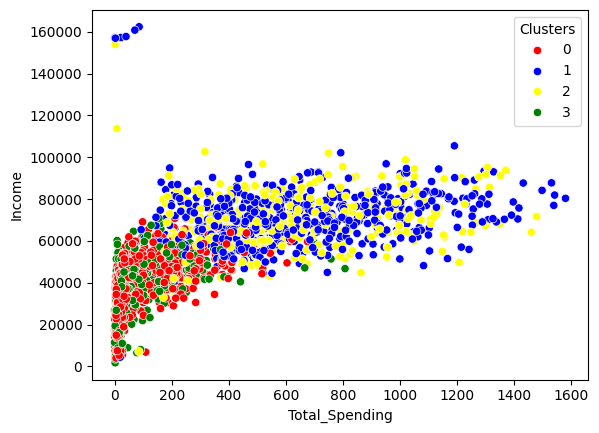

In [196]:
# Income & Spending patterns
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["Clusters"],palette=pal)

In [197]:
''' now lets observe the common characteristics in these 
clusters on the basis pf spending and the income '''

''' 
cluster 0 (red) => low/moderate Income
                   low/moderate Spending

cluster 1 (blue) => high Income
                   high Spending

cluster 2 (yellow) => moderate Income
                   high Spending

cluster 3 (green) => low Income
                   low Spending
'''


# and thats how we can identify further details abot clusters such as which clusters have more kids or which have higher age etc 
# thats how we can identify details about clusters

' \ncluster 0 (red) => low/moderate Income\n                   low/moderate Spending\n\ncluster 1 (blue) => high Income\n                   high Spending\n\ncluster 2 (yellow) => moderate Income\n                   high Spending\n\ncluster 3 (green) => low Income\n                   low Spending\n'

In [198]:
# we can create a cluster summary 

cluster_summary = X.groupby("Clusters").mean()  # lets look at mean value of every features cluster wise
print(cluster_summary)  # and we can analyze here features cluster wise

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         37093.250617  49.187654           2.517284         2.801235   
1         70825.329114  48.849684           2.169304         5.732595   
2         70301.151934  50.756906           1.911602         5.784530   
3         36828.442130  47.997685           2.543981         2.671296   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.760494           3.712346           6.533333  0.009877   
1                    5.058544           8.493671           3.776899  0.007911   
2                    4.969613           8.406077           3.803867  0.005525   
3                    0.793981           3.567130           6.567130  0.011574   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
Clu

In [ ]:
''' 
and thats how we can analyze different clusters and how each
or important features are behaving in different clusters 
and can plan our marketing strategies according to that 
we will group different customers according to clusters
and plan our compnies gtm according to that'''